In [16]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim = s.sim()
sim.transition = '+5/2<->-1/2'

In [3]:
sim.get_f()

In [4]:
P_bank = np.linspace(.02, .2, 11)

tpi_bank = np.logspace(-5, -3, 10)
P_bank = 3.4*1e-6/tpi_bank

In [5]:
sim.power_scaling(P_bank)

power scan progress:   0%|          | 0/10 [00:00<?, ?it/s]

spectroscopy, Pb = 340.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 203.82 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 122.19 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 73.25 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 26.32 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 15.78 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 9.46 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 5.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 3.4 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [8]:
sim.analytics(P_bank, sim_resonance = sim.w_num_bank)

<Figure size 2000x1500 with 0 Axes>

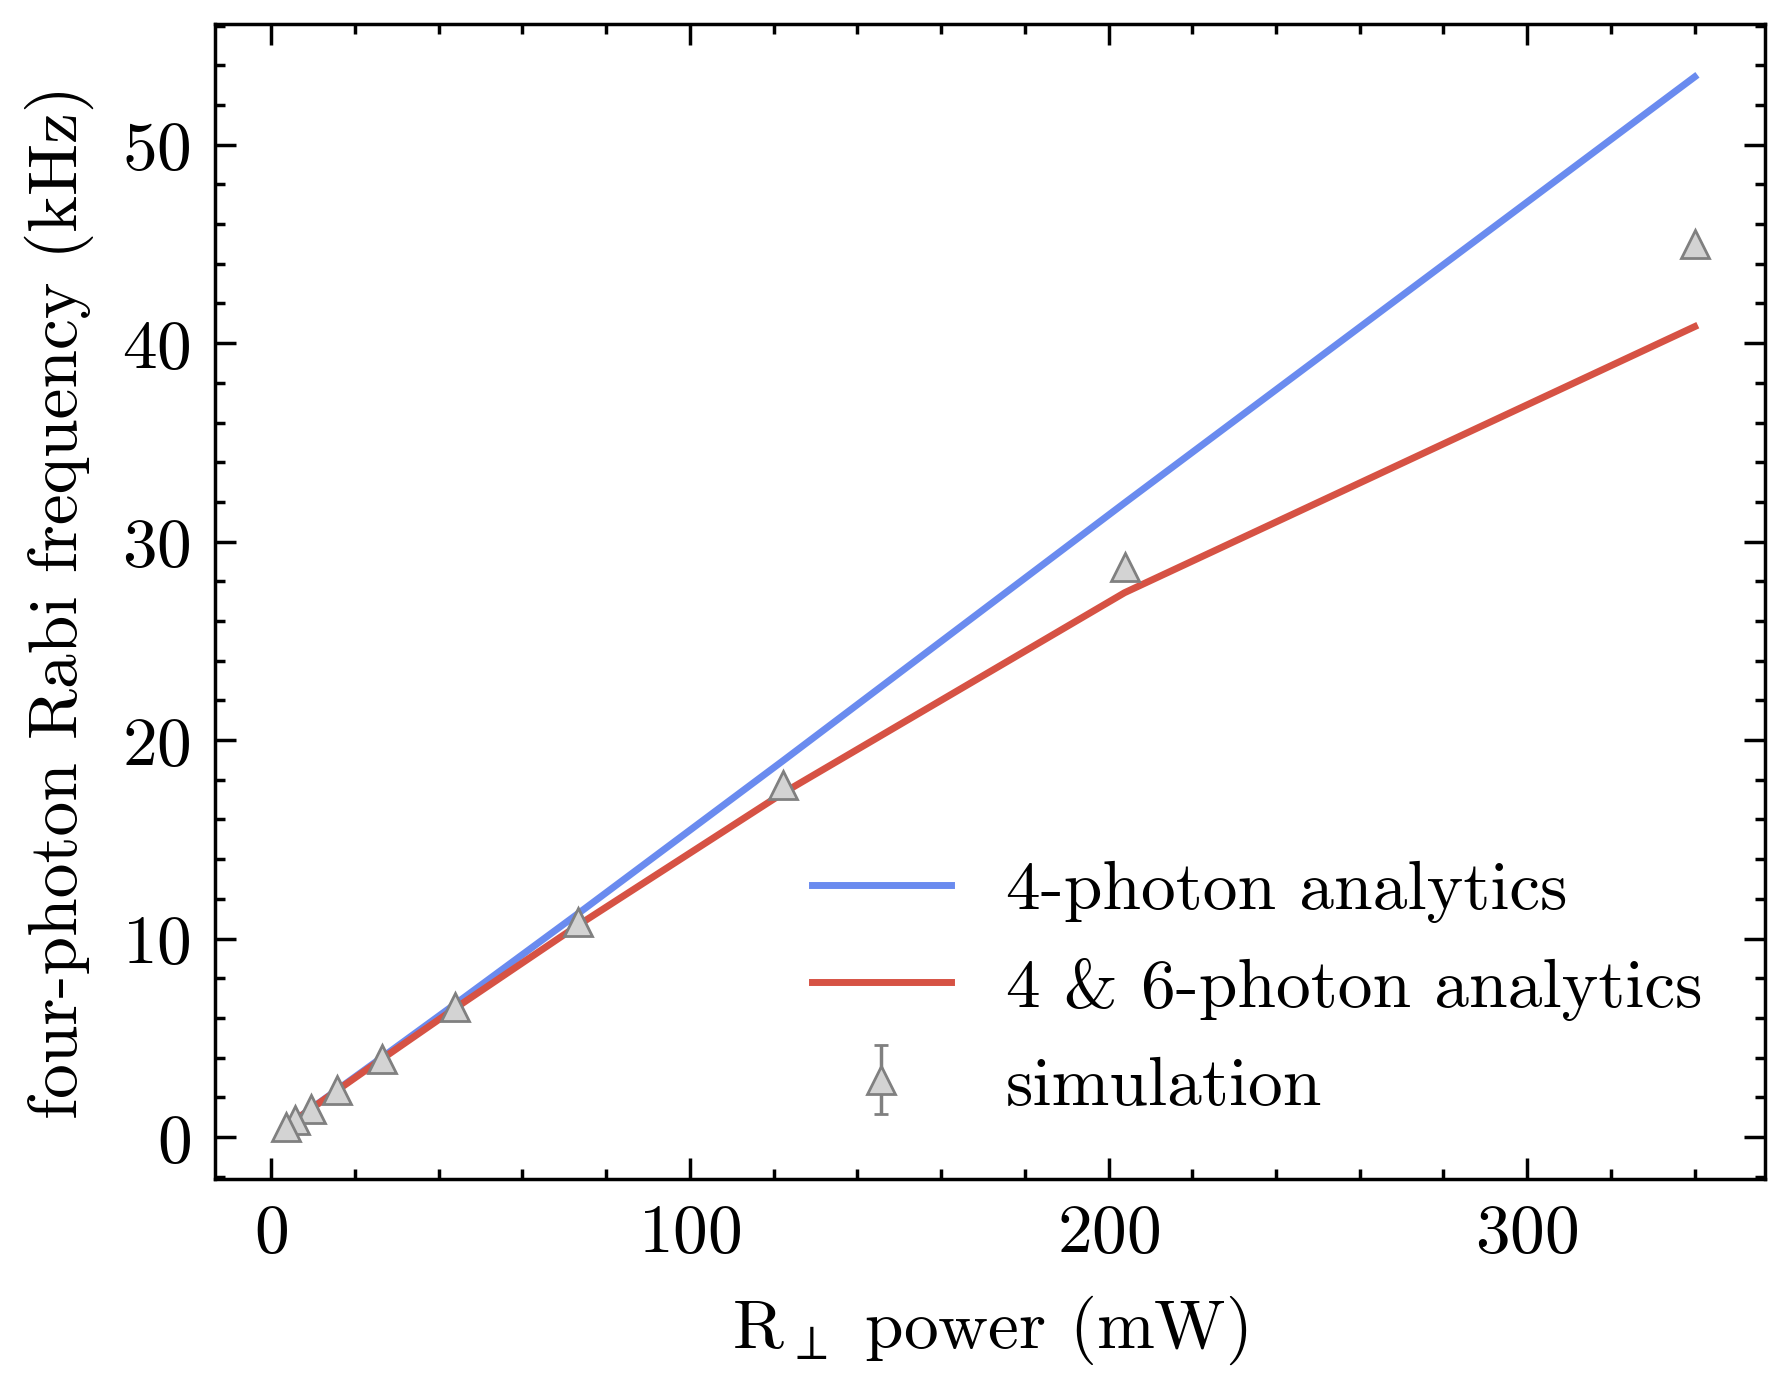

In [10]:
simulation = sim
with plt.style.context(['science', 'no-latex']):
    plt.figure(dpi = 500, figsize = (4,3))
    plt.errorbar(P_bank*1e3,simulation.Ω_num_bank/(2*np.pi*1e3), simulation.δΩ_num_bank/(2*np.pi*1e3),
         marker = '^' , ls = 'none', ecolor = 'gray', markeredgecolor = 'gray', markeredgewidth = .4, 
         markersize=4, capsize=1, elinewidth = .5,markerfacecolor='lightgray', alpha = 1, label='simulation')
    plt.plot(P_bank*1e3,(-simulation.Ω03_4/(2*np.pi*1e3)),
        color=cb_d, label='4-photon analytics')
    plt.plot(P_bank*1e3,((-simulation.Ω03_4 - simulation.Ω03_6)/(2*np.pi*1e3)),
            color=cr_d, label='4 & 6-photon analytics')
    plt.ylabel('four-photon Rabi frequency (kHz)')
    plt.xlabel(r'R$_\perp$ power (mW)')
    plt.legend(loc = 'lower right')
    plt.show()

In [12]:
Ω_sim = sim.Ω_num_bank/(2*np.pi*1e3)
δΩ_sim = sim.δΩ_num_bank/(2*np.pi*1e3)
Ω4 = (-sim.Ω03_4/(2*np.pi*1e3))
Ω6 = (-sim.Ω03_4 - simulation.Ω03_6)/(2*np.pi*1e3)

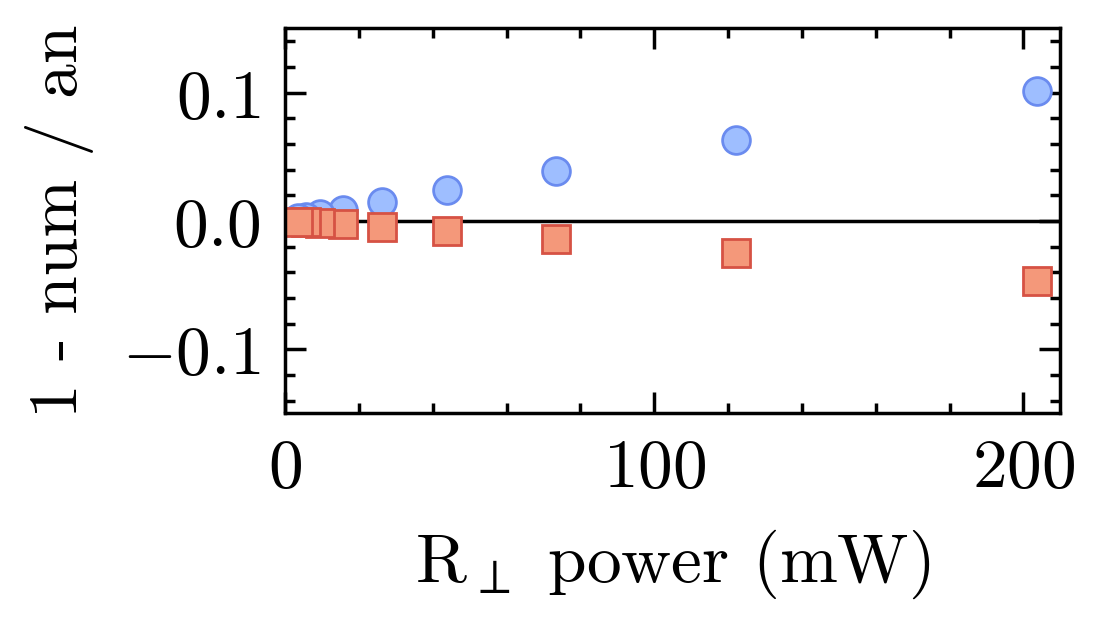

In [13]:
simulation = sim
with plt.style.context(['science', 'no-latex']):
    plt.figure(dpi = 500, figsize = (2,1))
    plt.errorbar(P_bank*1e3,abs(1-Ω_sim/Ω4), δΩ_sim/Ω4,
         marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
         markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1, label='4 + 6-photon')
    plt.errorbar(P_bank*1e3,1-Ω_sim/Ω6, δΩ_sim/Ω6,
         marker = 's' , ls = 'none', ecolor = cr_d, markeredgecolor = cr_d, markeredgewidth = .4, 
         markersize=4, capsize=1, elinewidth = .5,markerfacecolor=cr_l, alpha = 1, label='4 + 6-photon')
    plt.xlabel(r'R$_\perp$ power (mW)')
    plt.ylabel('1 - num / an')

    plt.xlim(0,210)
    plt.axhline(0, color = 'black', linewidth = .5)
    plt.ylim(-.15, .15)

    plt.show()

<Figure size 1500x1250 with 0 Axes>

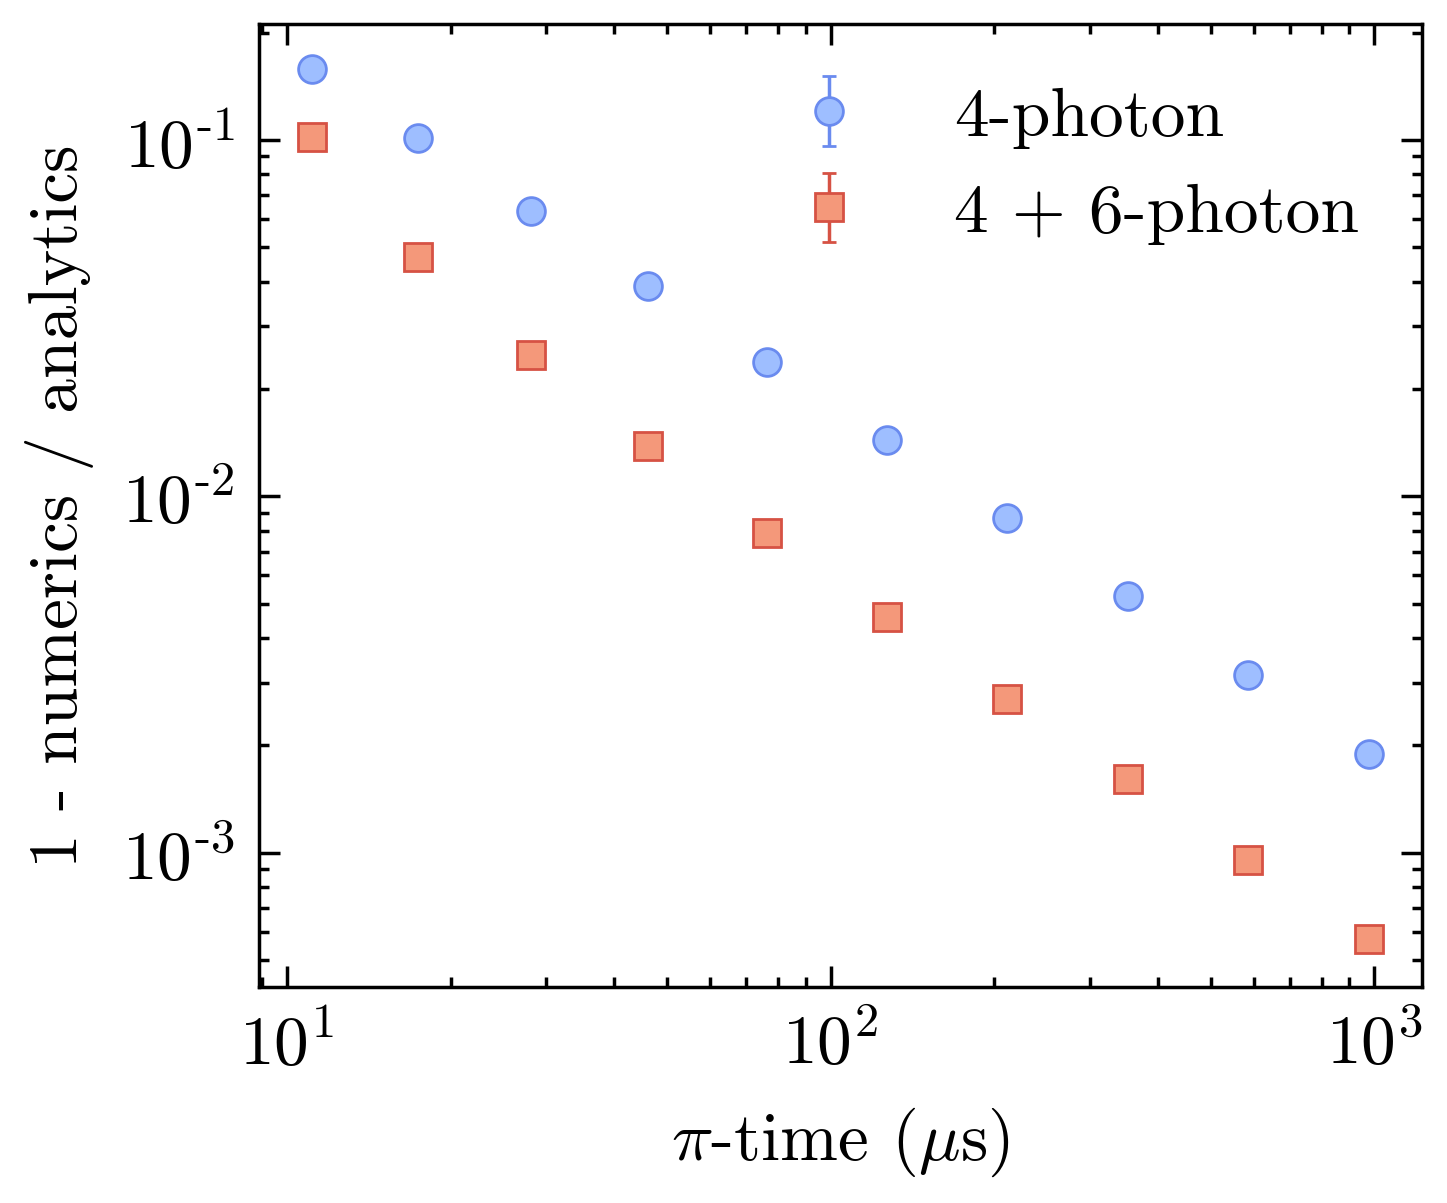

In [15]:
simulation = sim
with plt.style.context(['science', 'no-latex']):
    plt.figure(dpi = 500, figsize = (3,2.5))

    plt.errorbar(np.pi/(sim.Ω_num_bank*1e-6),abs(1-Ω_sim/Ω4), δΩ_sim/Ω4,
         marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
         markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1, label='4-photon')
    plt.errorbar(np.pi/(sim.Ω_num_bank*1e-6),abs(1-Ω_sim/abs(Ω6)), δΩ_sim/Ω6,
         marker = 's' , ls = 'none', ecolor = cr_d, markeredgecolor = cr_d, markeredgewidth = .4, 
         markersize=4, capsize=1, elinewidth = .5,markerfacecolor=cr_l, alpha = 1, label='4 + 6-photon')

    plt.xlabel(r'$\pi$-time ($\mu$s)')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.ylabel('1 - numerics / analytics')
    # plt.plot(x_fit*1e6,y6_fit, color = cr_l)
    # plt.plot(x_fit*1e6,y4_fit, color = cb_l)
    # plt.plot(x_fit*1e6,y6_fit2, color = cr_l)
    # plt.ylim(5e-3, .4)
    # plt.xlim(10, 3e3)
    plt.show()

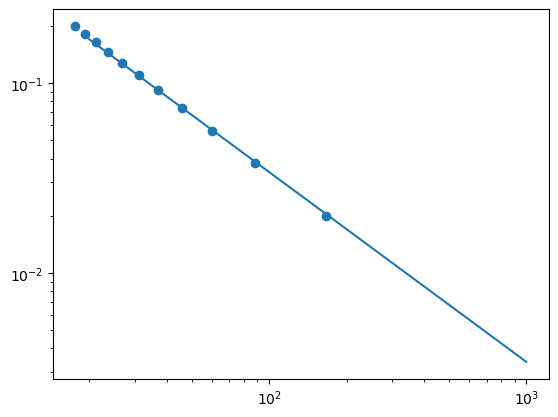

In [59]:
c4 = 3.4*1e-6

tpi_test = np.linspace(20, 1000, 1000)*1e-6
p_test = c4/tpi_test

plt.plot(tpi_test*1e6, p_test)
plt.scatter(np.pi/(sim.Ω4_num_bank)*1e6, P_bank)
# plt.ylim(0,.2)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [60]:
sim2 = s.sim()
sim2.transition = '+5/2<->-3/2'
sim2.get_f()

In [61]:
sim2.analytics(P_bank)

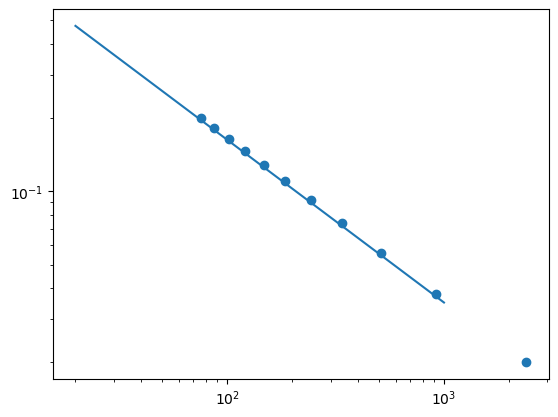

In [62]:
c6 = 3.5*1e-4

tpi_test = np.linspace(20, 1000, 10)*1e-6
p_test = c6/tpi_test**(2/3)

plt.plot(tpi_test*1e6, p_test)
plt.scatter(abs(np.pi/(sim2.Ω04_6))*1e6, P_bank)
# plt.ylim(0,.2)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [12]:
tpi_bank = np.logspace(-5, -3, 10)

In [13]:
tpi_bank*1e6

array([  10.        ,   16.68100537,   27.82559402,   46.41588834,
         77.42636827,  129.1549665 ,  215.443469  ,  359.38136638,
        599.48425032, 1000.        ])

In [14]:
P4 = 3.4*1e-6/tpi_bank

In [15]:
P4

array([0.34      , 0.20382465, 0.12218966, 0.07325078, 0.04391269,
       0.02632497, 0.0157814 , 0.0094607 , 0.00567154, 0.0034    ])

In [17]:
P6 = 3.5*1e-4/tpi_bank**(2/3)

In [18]:
P6

array([0.75405214, 0.53610916, 0.38115804, 0.27099229, 0.19266764,
       0.1369811 , 0.09738958, 0.06924116, 0.04922845, 0.035     ])